# Introduction

This section performs an exploratory data analysis (EDA) to understand the structure of the dataset, identify key patterns, and highlight early indicators related to customer churn.
We examine data distributions, correlations, differences between churn and non-churn groups, and potential data quality issues that may influence the modeling process.

In [1]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set consistent visual style for all plots (colors, sizes, theme)
sns.set_theme(style="whitegrid")

CHURN_COLOR = "#d62728"   # red for churned customers
RETAIN_COLOR = "#1f77b4"  # blue for retained customers

def set_plot_style():
    plt.rcParams['figure.figsize'] = (6,4)
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['axes.labelsize'] = 12
    plt.rcParams['xtick.labelsize'] = 10
    plt.rcParams['ytick.labelsize'] = 10
    plt.rcParams['figure.dpi'] = 120

set_plot_style()

In [3]:
# Global styling for plots and DataFrame display
plt.style.use('seaborn-v0_8')     # base style for clean visuals
sns.set_palette("Set2")           # softer color palette
pd.set_option('display.max_columns', None)  # show all columns when printing DataFrames

# 1. Load Data & Setup

In [4]:
import os

# Fix working directory if notebook runs from wrong place
CURRENT_DIR = os.getcwd()

if CURRENT_DIR.endswith("Users") or CURRENT_DIR.endswith("koutr"):
    PROJECT_DIR = r"C:\Users\koutr\OneDrive\Υπολογιστής\Bank Churn Project"
    os.chdir(PROJECT_DIR)
    CURRENT_DIR = os.getcwd()

print("Current working directory:", CURRENT_DIR)

# Build the RELATIVE path to the processed data
PROCESSED_DATA_PATH = os.path.join(
    CURRENT_DIR, 
    "data", 
    "processed", 
    "bank_churn_cleaned_final.csv"
)

print("Loading from:", PROCESSED_DATA_PATH)


# Load the processed dataset
df = pd.read_csv(PROCESSED_DATA_PATH)
df.head()

Current working directory: C:\Users\koutr\OneDrive\Υπολογιστής\Bank Churn Project
Loading from: C:\Users\koutr\OneDrive\Υπολογιστής\Bank Churn Project\data\processed\bank_churn_cleaned_final.csv


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,age_capped
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,42
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,41
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,42
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,39
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,43


In [5]:
df = df.drop(columns=['customer_id'])

In [6]:
df.dtypes

credit_score          int64
country              object
gender               object
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
age_capped            int64
dtype: object

In [7]:
# Fix data types to ensure correct behavior in modeling and statistical analysis

# Convert true binary/numeric variables to int
for col in ['churn', 'active_member', 'credit_card']:
    df[col] = df[col].astype(int)

# Convert nominal variables to categorical for memory efficiency and cleaner encoding
for col in ['country', 'gender']:
    df[col] = df[col].astype('category')

df['products_number'] = df['products_number'].astype(int)

# Quick check
df.dtypes

credit_score           int64
country             category
gender              category
age                    int64
tenure                 int64
balance              float64
products_number        int32
credit_card            int32
active_member          int32
estimated_salary     float64
churn                  int32
age_capped             int64
dtype: object

# 2. Data Quality

# 🧹 Data Quality Assessment

- In this section, we assess the quality of the data before any modeling or feature engineering is performed.

In [8]:
# Missing values overview
missing = (
    df.isna().sum()
      .to_frame("missing_count")
      .assign(missing_pct=lambda x: x["missing_count"] / len(df) * 100)
      .sort_values("missing_pct", ascending=False)
)

display(missing)

# Duplicates check
duplicate_rows = df.duplicated().sum()
duplicate_rows


# Data types & memory usage
df.info()

# Summary statistics for numerical features
df.describe().T

# Cardinality of categorical features
cat_cols = df.select_dtypes(include=['object','category']).columns
cardinality = {col: df[col].nunique() for col in cat_cols}
pd.DataFrame.from_dict(cardinality, orient='index', columns=['cardinality'])

,missing_count,missing_pct
credit_score,0,0.0
country,0,0.0
gender,0,0.0
age,0,0.0
tenure,0,0.0
balance,0,0.0
products_number,0,0.0
credit_card,0,0.0
active_member,0,0.0
estimated_salary,0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   credit_score      10000 non-null  int64   
 1   country           10000 non-null  category
 2   gender            10000 non-null  category
 3   age               10000 non-null  int64   
 4   tenure            10000 non-null  int64   
 5   balance           10000 non-null  float64 
 6   products_number   10000 non-null  int32   
 7   credit_card       10000 non-null  int32   
 8   active_member     10000 non-null  int32   
 9   estimated_salary  10000 non-null  float64 
 10  churn             10000 non-null  int32   
 11  age_capped        10000 non-null  int64   
dtypes: category(2), float64(2), int32(4), int64(4)
memory usage: 644.9 KB


,cardinality
country,3
gender,2


# Summary — Data Quality

- There are no missing values or duplicates; all fields contain 10,000 valid rows.

- Data types and values are clean, with no out-of-range issues.

- Cardinality levels are appropriate (gender/country low, age_group medium).

## 3. Outlier Analysis

- We check for the presence of extreme values in the numerical features.

In [9]:
# Detect outliers using the IQR method for all numerical features (excluding the target).
# The procedure calculates Q1, Q3, and IQR, then flags values outside 1.5 * IQR as outliers.
# Returns a summary table with outlier counts and percentages for each feature.
outlier_report = []

for col in df.select_dtypes(include=["int64", "float64"]).columns:
    if col == "churn": 
        continue
    
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = outliers / len(df) * 100
    
    outlier_report.append({
        "feature": col,
        "outliers_count": outliers,
        "outliers_pct": pct,
        "Q1": q1,
        "Q3": q3,
    })

pd.DataFrame(outlier_report).sort_values("outliers_pct", ascending=False)

,feature,outliers_count,outliers_pct,Q1,Q3
1,age,359,3.59,32.00,44.0000
5,age_capped,359,3.59,32.00,44.0000
0,credit_score,15,0.15,584.00,718.0000
2,tenure,0,0.00,3.00,7.0000
3,balance,0,0.00,0.00,127644.2400
4,estimated_salary,0,0.00,51002.11,149388.2475


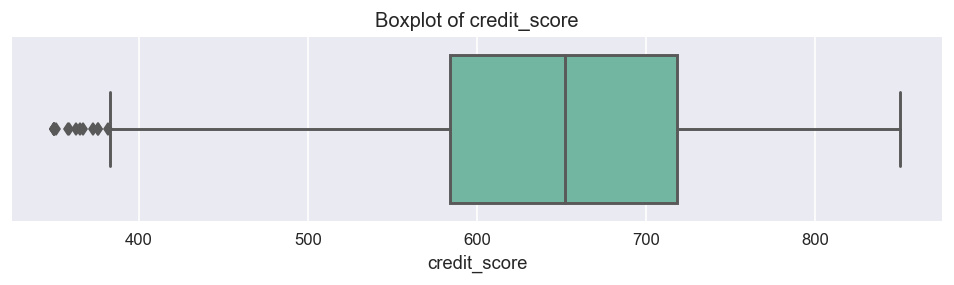

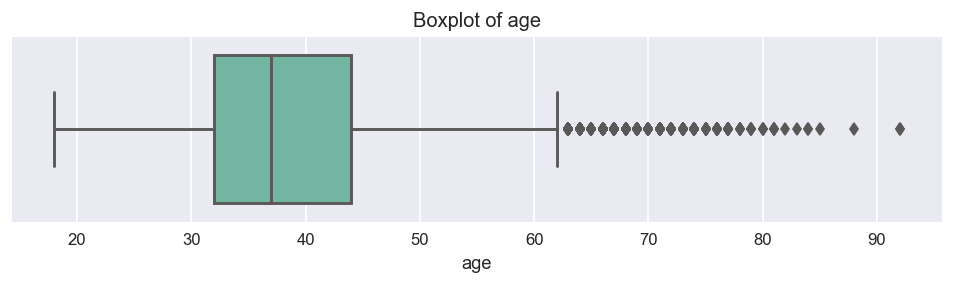

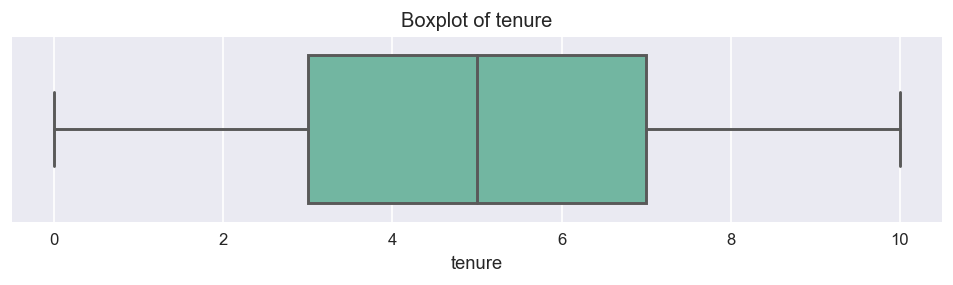

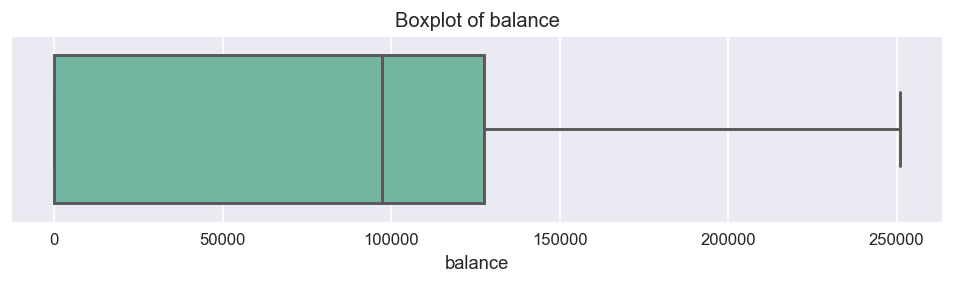

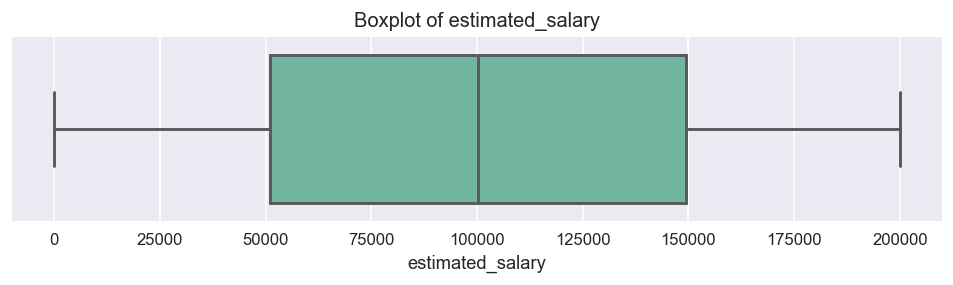

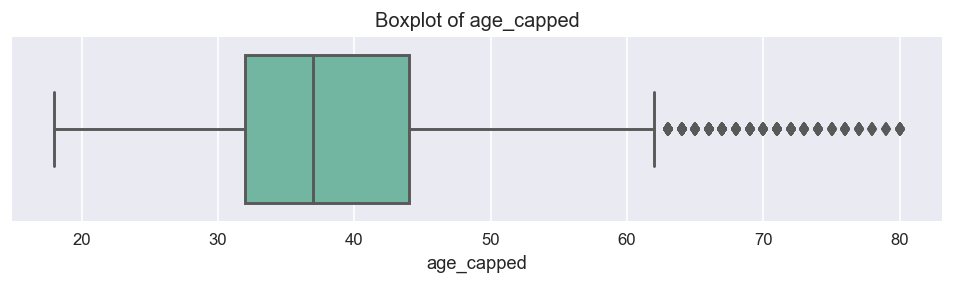

In [10]:
for col in df.select_dtypes(include=["int64", "float64"]).columns:
    if col == "churn":
        continue
    
    plt.figure(figsize=(10, 2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# Summary — Outlier Analysis

- Outliers are mainly found in age / age_capped (~3.6%), but the values appear realistic.

- Credit Score has very few outliers (~0.15%), while Tenure, Balance, and Salary show none.

- Overall, the dataset is stable and does not require correction during EDA.

- Optional capping for age may be considered during modeling.

## 🚨 Potential Leakage Check

- We identify variables that may contain information available only after the churn event, as well as variables that uniquely identify a customer (IDs).

- These features should not be used in the modeling process.

In [11]:
# Identify ID-like columns (unique identifiers that should not be used as features)
id_like = [col for col in df.columns if "id" in col.lower() or "ID" in col]
id_like

[]

# 4. Target Variable Overview

# Target Balance Check

- We examine the class distribution (churn vs. non-churn).

In [12]:
# Define the target column
target = "churn"

# Value counts of the target variable
counts = df[target].value_counts()
percentages = df[target].value_counts(normalize=True) * 100

# Shows how many samples belong to each class
display(counts.to_frame("count"))
display(percentages.to_frame("pct %"))

,count
0,7963
1,2037


,pct %
0,79.63
1,20.37


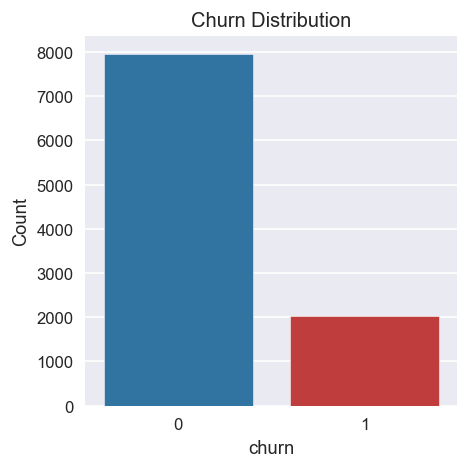

In [13]:
# Visualizing the distribution of the target variable
plt.figure(figsize=(4,4))
sns.countplot(
    data=df, x=target,
    palette=[RETAIN_COLOR, CHURN_COLOR]
)
plt.title("Churn Distribution")
plt.ylabel("Count")
plt.show()

In [14]:
# Calculate churn rate
churn_rate = df[target].mean() * 100
print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 20.37%


# Summary — Target Variable Overview

- The target variable is clean, with no missing values.

- Churn rate: 20.37%, indicating a clear class imbalance (~80/20).

- The distribution is realistic and shows no irregularities.

In [15]:
# Inspect class distribution of the target variable (churn)
# Shows unique values, raw counts, and percentage proportions to assess class imbalance.
print("Unique values:", df['churn'].unique())
print("\nCounts:")
print(df['churn'].value_counts())

print("\nProportions (%):")
print((df['churn'].value_counts(normalize=True) * 100).round(2))

Unique values: [1 0]

Counts:
0    7963
1    2037
Name: churn, dtype: int64

Proportions (%):
0    79.63
1    20.37
Name: churn, dtype: float64


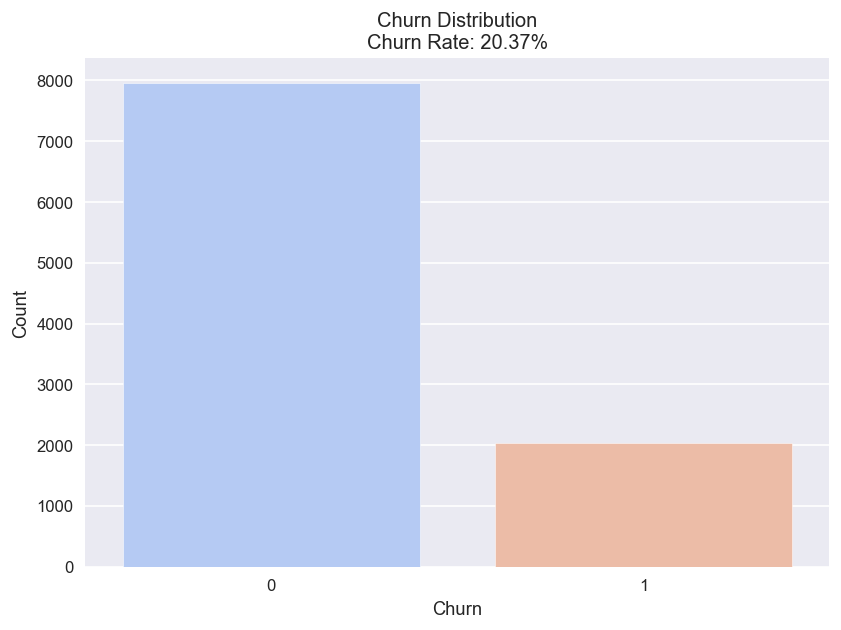

In [16]:
# Countplot
sns.countplot(x='churn', data=df, palette='coolwarm')
plt.title(f"Churn Distribution\nChurn Rate: {df['churn'].mean()*100:.2f}%")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

In [17]:
# Compute the churn rate with a 95% confidence interval using the Wilson method.
# This provides an estimate of the true churn proportion and its statistical uncertainty.
from statsmodels.stats.proportion import proportion_confint

p = df['churn'].mean()
n = len(df)
low, high = proportion_confint(int(p*n), n, method="wilson")

print(f"Ποσοστό αποχωρήσεων: {p*100:.2f}% (95% ΔΕ: {low*100:.2f}% – {high*100:.2f}%)")

Ποσοστό αποχωρήσεων: 20.37% (95% ΔΕ: 19.59% – 21.17%)


In [18]:
# Segment churn
segment_cols = ['gender', 'country', 'active_member', 'products_number']

for col in segment_cols:
    print(f"\n Churn rate by {col}:")
    print((df.groupby(col)['churn'].mean() * 100).round(2))


 Churn rate by gender:
gender
Female    25.07
Male      16.46
Name: churn, dtype: float64

 Churn rate by country:
country
France     16.15
Germany    32.44
Spain      16.67
Name: churn, dtype: float64

 Churn rate by active_member:
active_member
0    26.85
1    14.27
Name: churn, dtype: float64

 Churn rate by products_number:
products_number
1     27.71
2      7.58
3     82.71
4    100.00
Name: churn, dtype: float64


**Insights**

- The overall churn rate is approximately 20%, with a 95% confidence interval ranging from 19.60% to 21.17%.

- The dataset exhibits a moderate class imbalance, but not severe enough to require special handling during the EDA stage.

- Female customers show a higher churn rate than male customers.

- Germany has nearly double the churn of France and Spain.

- Inactive customers have a significantly higher likelihood of leaving.

- Customers with many products show unexpectedly high churn, possibly due to smaller sample sizes in these groups.

# 5. **Numerical Distributions by Churn**

- In this section, we examine all numerical features in the dataset to understand their distributions, identify potential outliers, and assess linear correlations between them.

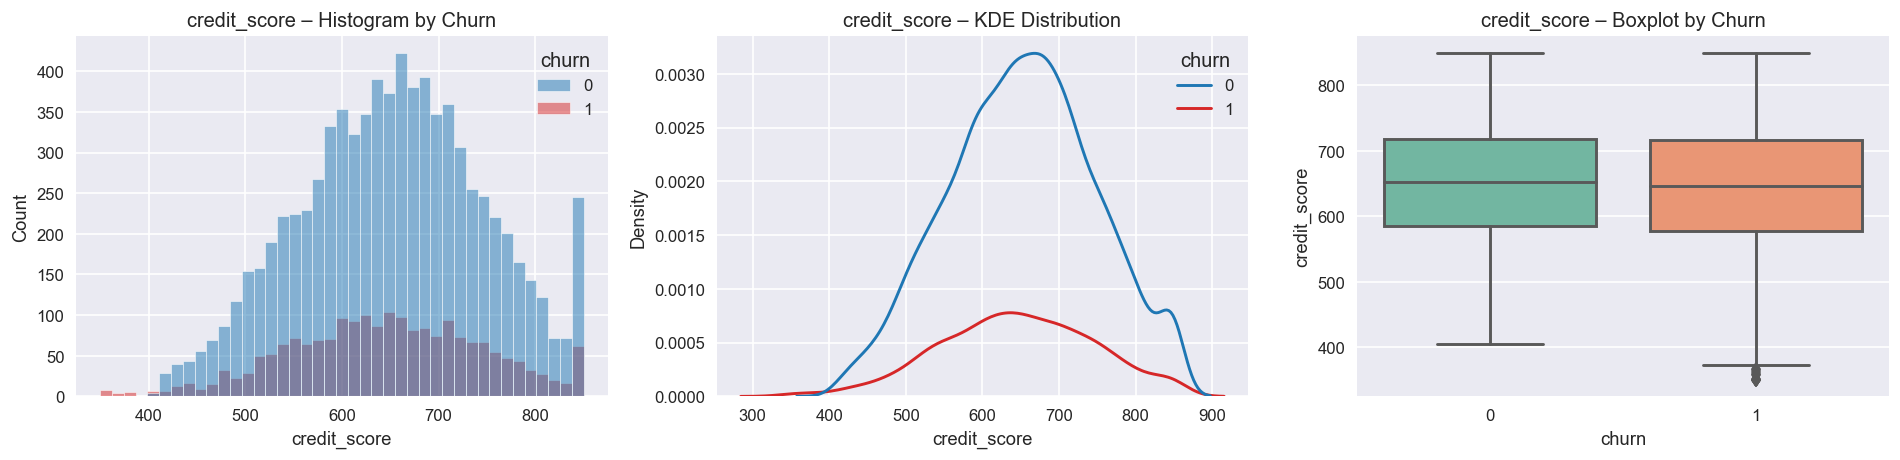

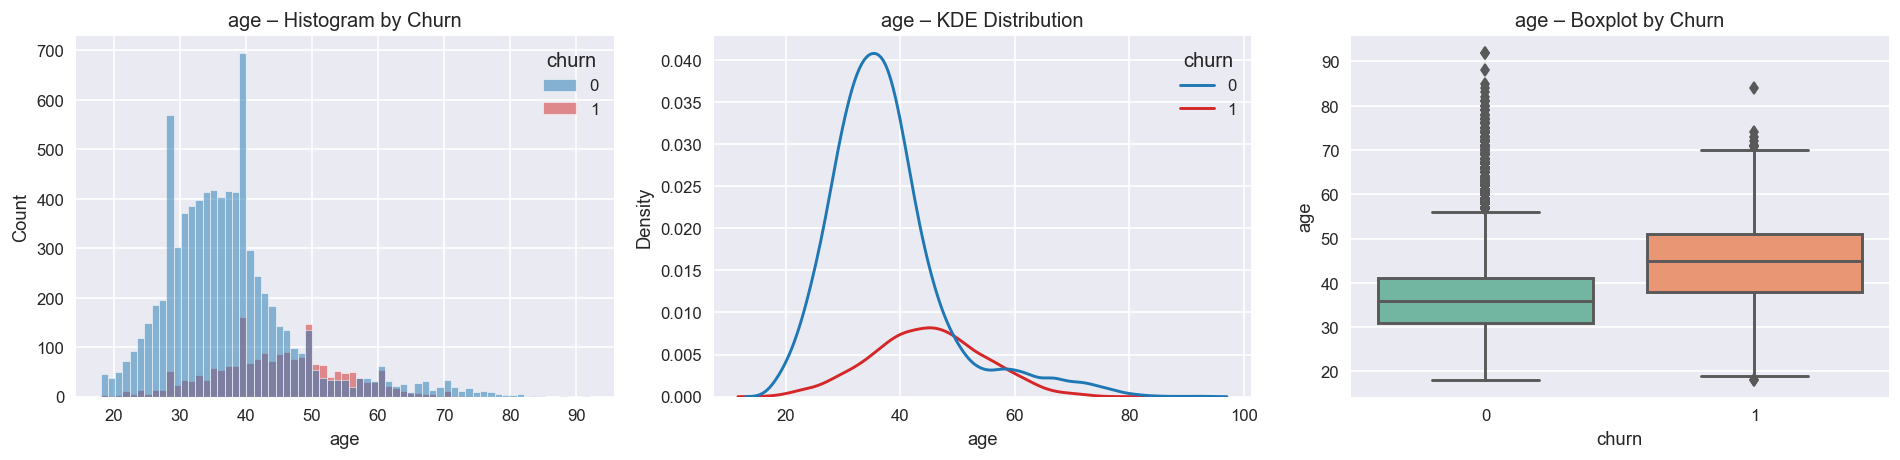

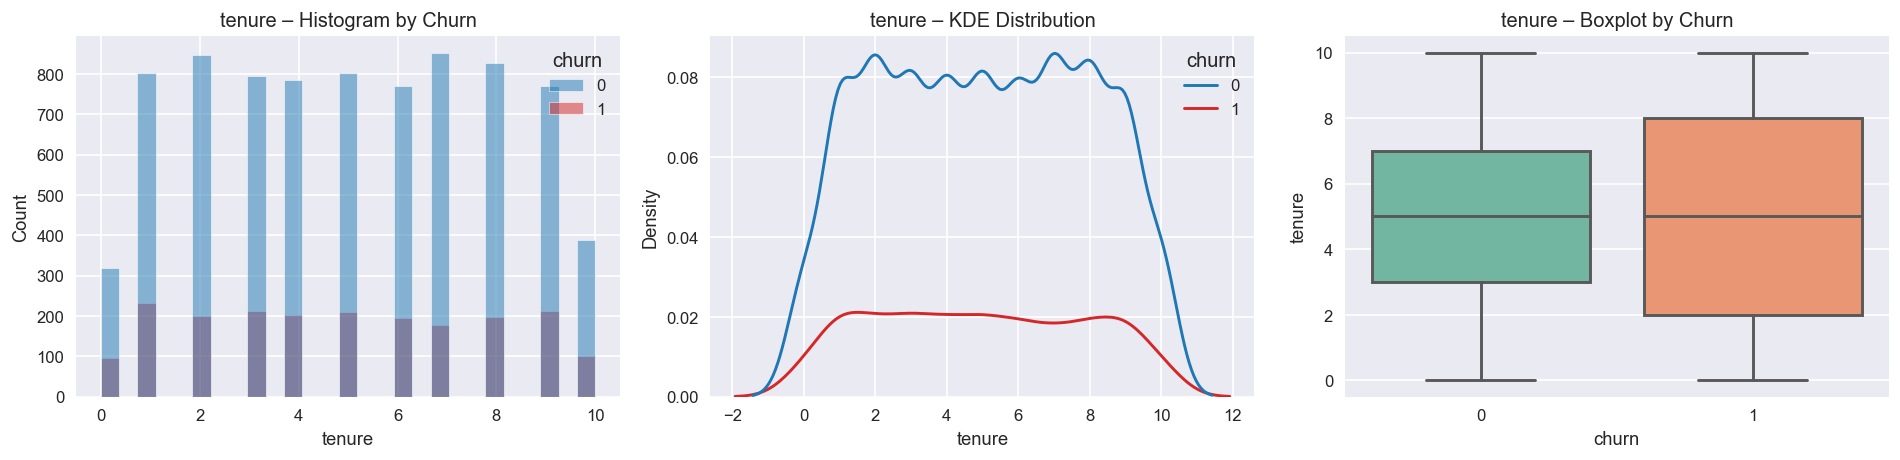

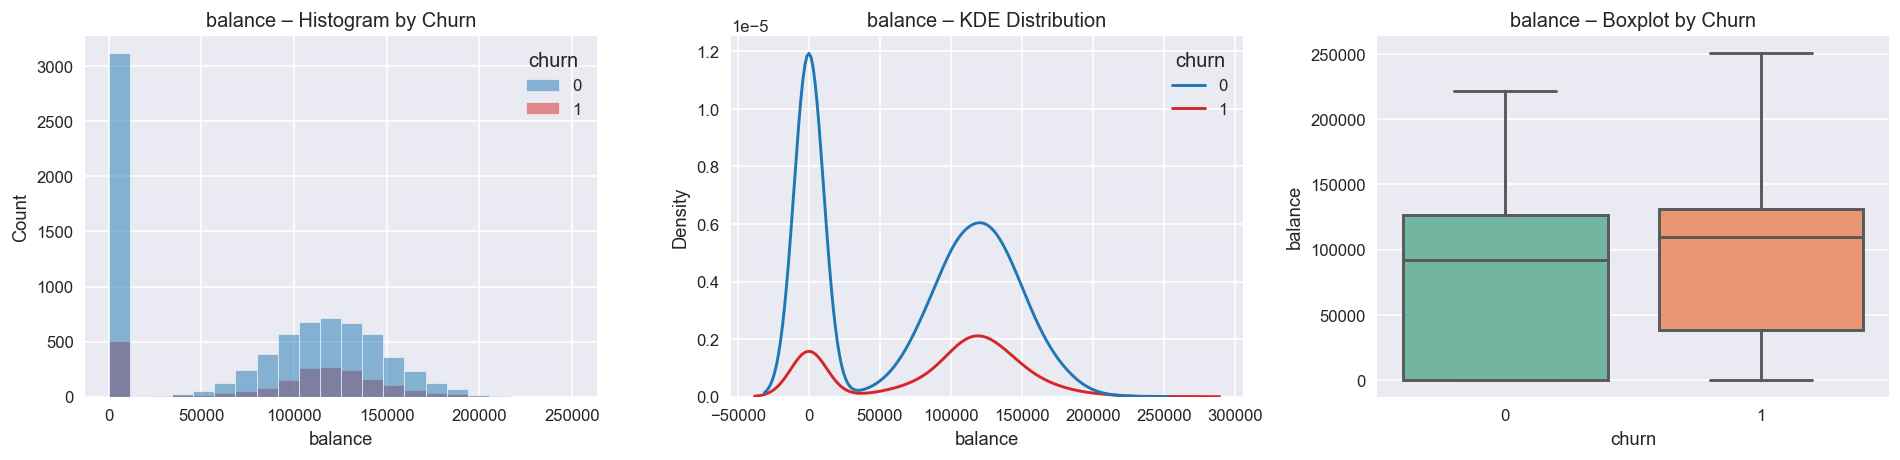

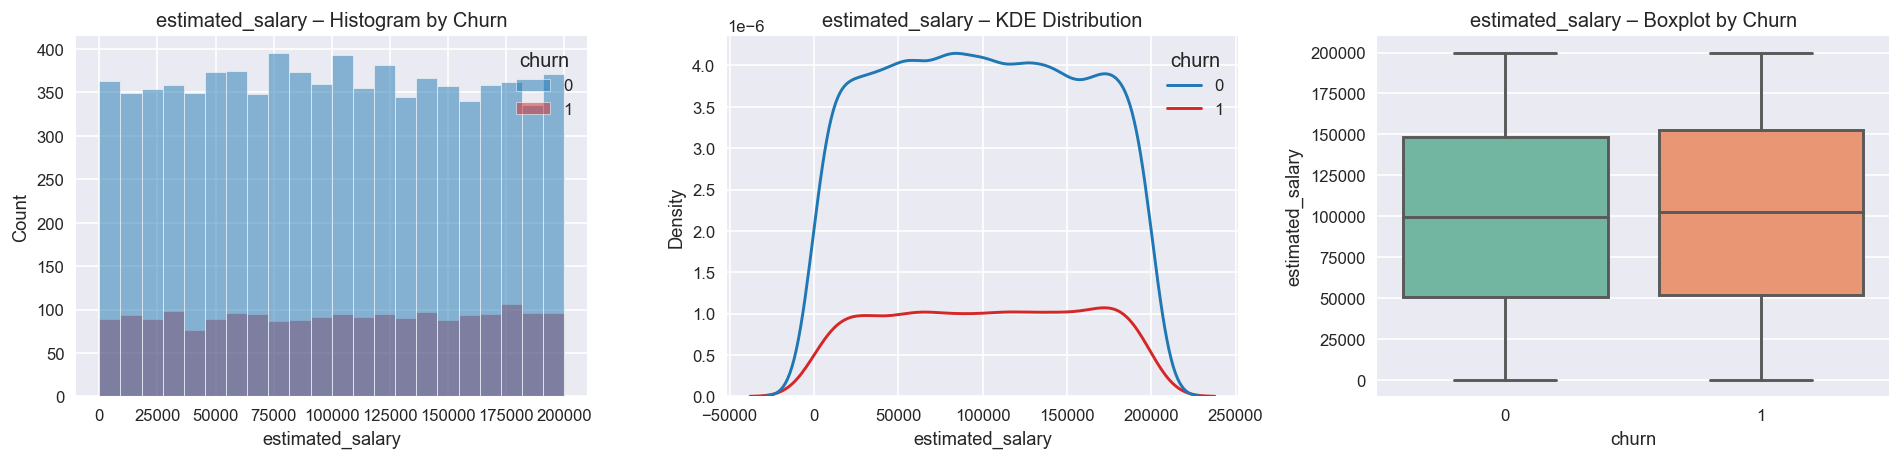

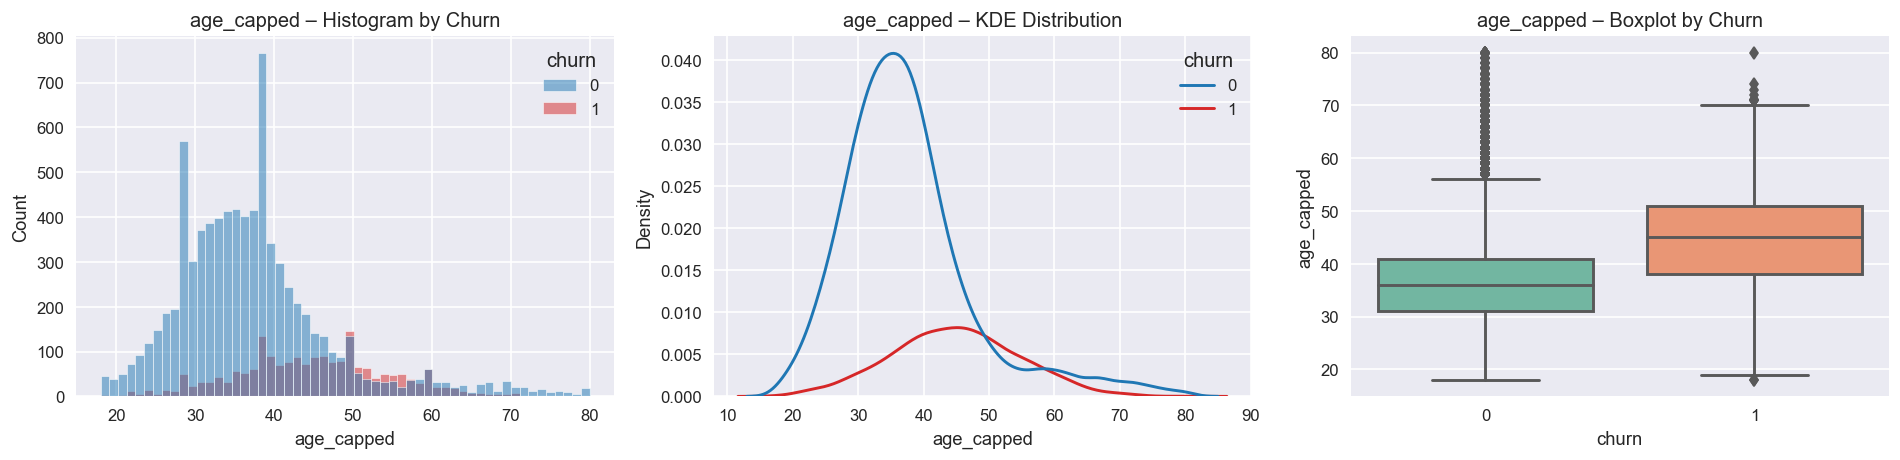

In [19]:
# Visualize numerical features across churn vs non-churn groups.
# For each numeric variable, we generate:
# Histogram by churn class
# KDE distribution to compare density shapes
# Boxplot to highlight differences in medians, spread, and outliers
# This helps identify distributional shifts and potential churn-related patterns.
# Select numerical features excluding churn and customer_id
num_features = df.select_dtypes(include=['int64', 'float64']).columns
num_features = [col for col in num_features if col not in ['churn', 'customer_id']]

for col in num_features:
    plt.figure(figsize=(16, 4))

    
    # Histogram 
    plt.subplot(1, 3, 1)
    sns.histplot(
    data=df, x=col, hue='churn',
    palette=[RETAIN_COLOR, CHURN_COLOR],
    kde=False, stat='count'
)

    plt.title(f"{col} – Histogram by Churn")


    # KDE 
    plt.subplot(1, 3, 2)
    sns.kdeplot(
    data=df, x=col, hue='churn',
    palette=[RETAIN_COLOR, CHURN_COLOR],
    fill=False
)

    plt.title(f"{col} – KDE Distribution")

  
    # Boxplot 
    plt.subplot(1, 3, 3)
    sns.boxplot(data=df, x='churn', y=col)
    plt.title(f"{col} – Boxplot by Churn")

    plt.tight_layout()
    plt.show()

In [20]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop('churn', errors='ignore')
num_cols

Index(['credit_score', 'age', 'tenure', 'balance', 'products_number',
       'credit_card', 'active_member', 'estimated_salary', 'age_capped'],
      dtype='object')

In [21]:
# Generate a descriptive statistics summary for all numerical features.
# For each variable, the function computes central tendency, dispersion,
# distribution shape (skewness, kurtosis), and quartiles.
# Returns a clean table useful for identifying asymmetries, outliers,
# and general distribution properties.
from scipy.stats import skew, kurtosis

def numeric_summary(df):
    summary = []
    for col in num_cols:
        s = df[col].dropna()
        summary.append({
            "Feature": col,
            "Count": len(s),
            "Mean": s.mean(),
            "Median": s.median(),
            "Std": s.std(),
            "Min": s.min(),
            "25%": s.quantile(0.25),
            "50%": s.quantile(0.50),
            "75%": s.quantile(0.75),
            "Max": s.max(),
            "Skewness": skew(s),
            "Kurtosis": kurtosis(s)
        })
    return pd.DataFrame(summary).round(3)

summary_df = numeric_summary(df)
summary_df

,Feature,Count,Mean,Median,Std,Min,25%,50%,75%,Max,Skewness,Kurtosis
0,credit_score,10000,650.529,652.000,96.653,350.00,584.00,652.000,718.000,850.00,-0.072,-0.426
1,age,10000,38.922,37.000,10.488,18.00,32.00,37.000,44.000,92.00,1.011,1.394
2,tenure,10000,5.013,5.000,2.892,0.00,3.00,5.000,7.000,10.00,0.011,-1.165
3,balance,10000,76485.889,97198.540,62397.405,0.00,0.00,97198.540,127644.240,250898.09,-0.141,-1.489
4,products_number,10000,1.530,1.000,0.582,1.00,1.00,1.000,2.000,4.00,0.745,0.582
5,credit_card,10000,0.706,1.000,0.456,0.00,0.00,1.000,1.000,1.00,-0.902,-1.187
6,active_member,10000,0.515,1.000,0.500,0.00,0.00,1.000,1.000,1.00,-0.060,-1.996
7,estimated_salary,10000,100090.240,100193.915,57510.493,11.58,51002.11,100193.915,149388.248,199992.48,0.002,-1.182
8,age_capped,10000,38.916,37.000,10.465,18.00,32.00,37.000,44.000,80.00,0.991,1.268


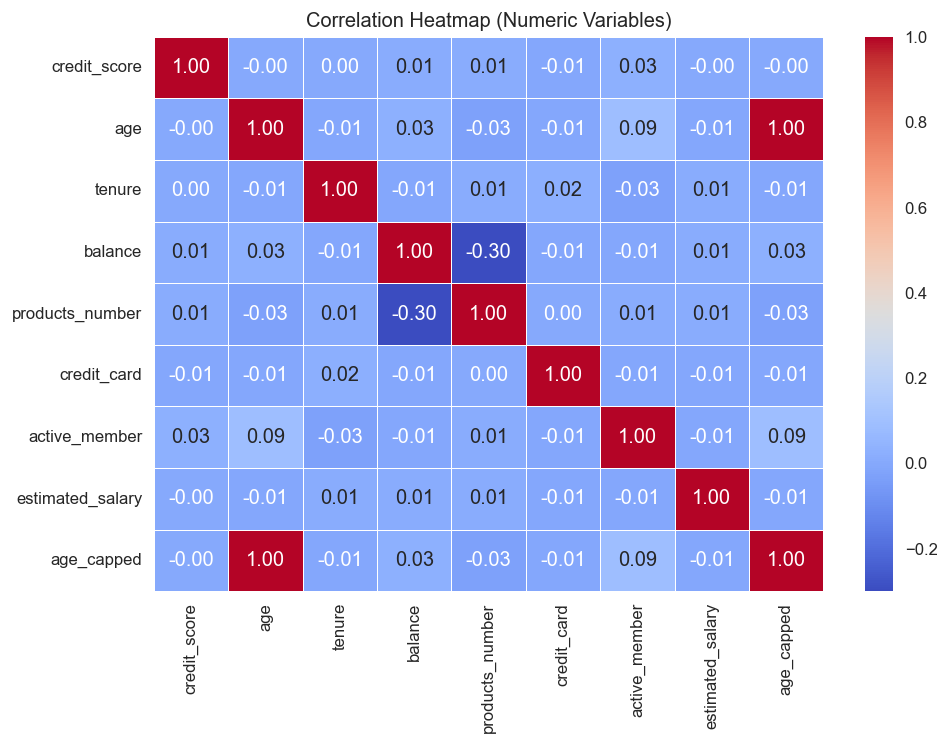

In [22]:
num_df = df[num_cols]
corr_matrix = num_df.corr().round(2)

plt.figure(figsize=(9,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Numeric Variables)")
plt.show()


# 6. Categorical Features Analysis

# Categorical Features Analysis

- In this section, we analyze the categorical variables and their relationship with the probability of customer churn.

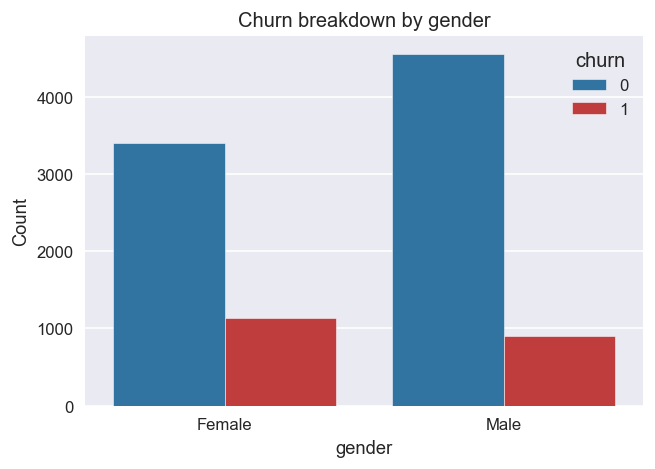


Churn Rate (%) by gender:


gender
Female    25.07
Male      16.46
Name: churn, dtype: float64

------------------------------------------------------------


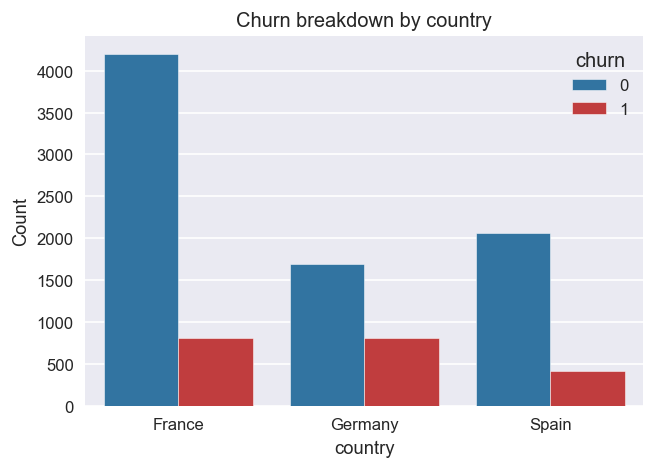


Churn Rate (%) by country:


country
France     16.15
Germany    32.44
Spain      16.67
Name: churn, dtype: float64

------------------------------------------------------------


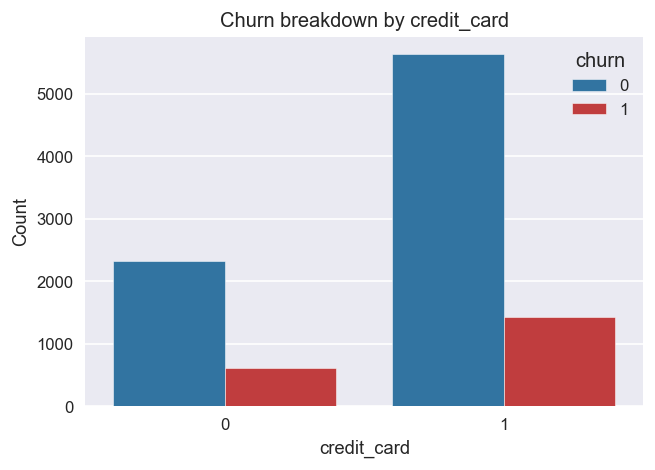


Churn Rate (%) by credit_card:


credit_card
0    20.81
1    20.18
Name: churn, dtype: float64

------------------------------------------------------------


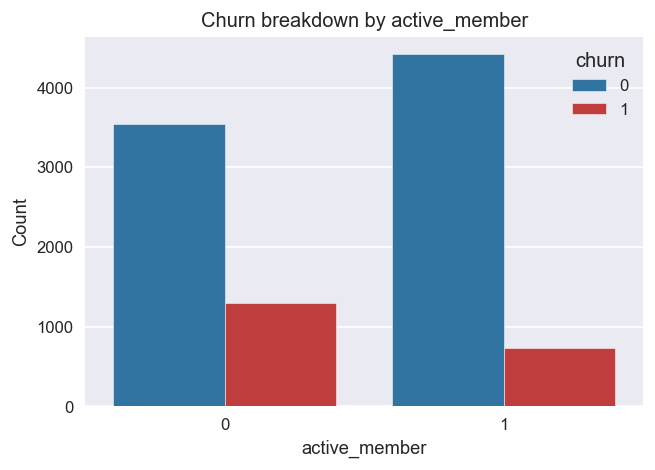


Churn Rate (%) by active_member:


active_member
0    26.85
1    14.27
Name: churn, dtype: float64

------------------------------------------------------------


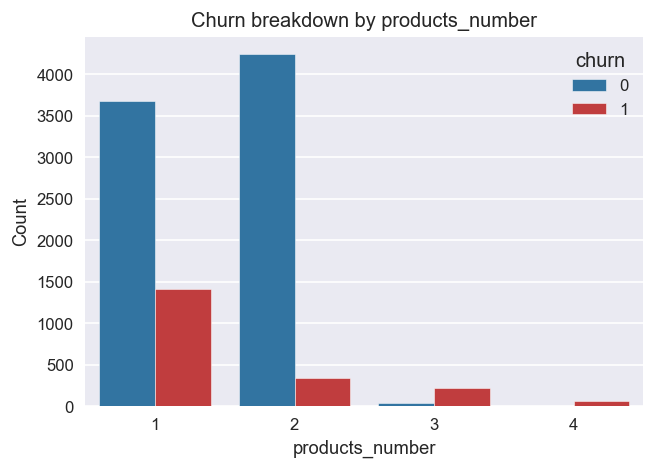


Churn Rate (%) by products_number:


products_number
1     27.71
2      7.58
3     82.71
4    100.00
Name: churn, dtype: float64

------------------------------------------------------------


In [23]:
cat_cols = ['gender', 'country', 'credit_card', 'active_member', 'products_number']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(
    x=col, hue='churn', data=df,
    palette=[RETAIN_COLOR, CHURN_COLOR]
)
    plt.title(f"Churn breakdown by {col}")
    plt.ylabel("Count")
    plt.show()

    print(f"\nChurn Rate (%) by {col}:")
    display((df.groupby(col)['churn'].mean() * 100).round(2))
    print("-"*60)

# 🧾 Final Summary — Basic EDA

- The dataset is clean, with no missing values or data quality issues.

- Outliers appear only in age (~3.6%) and are realistic rather than errors.

- Churn rate is 20.37%, showing a clear class imbalance (~80/20).

- Numerical features have smooth distributions and no strong multicollinearity.

- Among categorical variables, the strongest patterns relate to products_number, active_member, and country.

- Gender shows a small effect, while credit_card has essentially no predictive value.

- Overall, the data is well-prepared for Feature Engineering and more advanced statistical analysis.